In [3]:
%load_ext autoreload
%autoreload 2
from hmr.load import DATAFRAME
from hmr.load import select_balanced_eye_set

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
subset = select_balanced_eye_set(DATAFRAME, n=200, task="dr", seed=0)

subset = subset.merge(
    DATAFRAME[["id_patient", "session", "ICDR_DME_OD", "ICDR_DME_OS"]],
    on=["id_patient", "session"],
    how="left",
)
subset.iloc[20]

selected 200 images from 200 patients
grade
0    44
1    44
2    44
3    43
4    25


id_patient                14867774
session                        328
Date           2016-09-16 00:00:00
eye                             OD
grade                            4
ICDR_DME_OD                      2
ICDR_DME_OS                      2
Name: 20, dtype: object

In [5]:
import cv2

from hmr.predictions import predict_lesions, predict_od_mac, predict_DR, predict_DME

img = cv2.imread(
    "/home/clement/Documents/data/IVisionHMR/output/selected_FoV/5551/OD/macula.jpeg"
)

lesions = predict_lesions(img[:, :, ::-1], target_size=1536)
od_mac = predict_od_mac(img[:, :, ::-1], target_size=1024)

In [6]:
dr = predict_DR(img[:, :, ::-1])

In [7]:
dme = predict_DME(img[:, :, ::-1], lesions, od_mac)
dme

'M6'

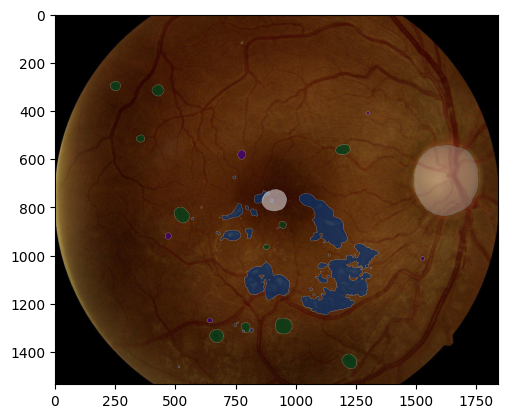

In [8]:
import matplotlib.pyplot as plt

cmaps = ["Reds", "Blues", "Greens", "Purples", "Oranges"]
plt.imshow(img[:, :, ::-1])
for (k, v), cmap in zip(lesions.items(), cmaps):
    plt.imshow(v, alpha=v.astype(float) * 0.75, cmap=cmap)

plt.imshow(od_mac["mask"], alpha=(od_mac["mask"] > 0).astype(float) * 0.5, cmap="gray")
plt.show()

In [9]:
od_mac

{'mask': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 'od_center': array([1620.31927315,  687.58490891]),
 'macula_center': array([908.760527  , 772.49741669]),
 'od_valid': True,
 'macula_valid': True}